# Project 1: Exploring World City Populations

In this project I work with a new dataset of 5,000 large cities around the world. The dataset includes each city's name, country, population, and location (latitude/longitude).

My goals are:

- Practice basic data wrangling with pandas.
- Compute the mean, median, and mode of city populations with pandas.
- Build a simple text-based visualization using only the standard library.

The dataset I use is:

- `world_cities_5000.csv` from World Cities Database: https://simplemaps.com/data/world-cities

This file keeps only cities with population greater than 5,000 and includes their population and basic geographic information.

## Data Sources

I start by loading the dataset. I use pandas.read_csv(), and I avoid hard-coding values so the notebook will still work if more rows are added.

In [3]:
import pandas as pd

file_path = "world_cities_5000.csv"

cities = pd.read_csv(file_path)

cities.head()

,city,country,population,density,lat,lng
0,Beijing_271,China,21894696,1351,39.766607,116.269798
1,Karachi_88,Pakistan,15364577,21000,24.921055,66.823665
2,Chongqing_294,China,13111004,4548,29.609993,106.596261
3,Chongqing_49,China,16544723,3647,29.381666,106.741102
4,Kolkata_190,India,12418202,23041,22.525585,88.557192


The `world_cities_5000.csv` file has 5,000 rows, one for each city, and six columns:

- `city`: city name (sometimes with a numeric suffix).
- `country`: country name.
- `population`: estimated population (integer).
- `density`: population density (people per square kilometer).
- `lat`, `lng`: latitude and longitude.

First I check the basic structure and make sure there are no duplicate rows or clearly invalid population values.

In [16]:
print("Shape:", cities.shape)
print("Columns:", list(cities.columns))

cities.info()

cities = cities.drop_duplicates()
cities = cities[cities["population"] > 0]

missing_pop = cities["population"].isna().sum()
print("Missing population values:", missing_pop)

cities.head()

Shape: (5000, 7)
Columns: ['city', 'country', 'population', 'density', 'lat', 'lng', 'city_clean']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        5000 non-null   object 
 1   country     5000 non-null   object 
 2   population  5000 non-null   int64  
 3   density     5000 non-null   int64  
 4   lat         5000 non-null   float64
 5   lng         5000 non-null   float64
 6   city_clean  5000 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 273.6+ KB
Missing population values: 0


,city,country,population,density,lat,lng,city_clean
0,Beijing_271,China,21894696,1351,39.766607,116.269798,Beijing
1,Karachi_88,Pakistan,15364577,21000,24.921055,66.823665,Karachi
2,Chongqing_294,China,13111004,4548,29.609993,106.596261,Chongqing
3,Chongqing_49,China,16544723,3647,29.381666,106.741102,Chongqing
4,Kolkata_190,India,12418202,23041,22.525585,88.557192,Kolkata


Because a city appears many times (e.g., Tokyo has 200+ entries), I combine them by taking the maximum population for each city.

In [18]:
cities["city_clean"] = cities["city"].str.split('_').str[0]

df_city = cities.groupby("city_clean", as_index=False)["population"].max()

top20 = df_city.sort_values(by="population", ascending=False).head(20)
top20

,city_clean,population
19,Tokyo,44861819
4,Delhi,34212644
16,Shanghai,30677065
17,São Paulo,25934566
13,Mexico City,25887744
14,Mumbai,25851077
2,Cairo,24084834
0,Beijing,24007008
5,Dhaka,23463177
15,Osaka,23103412


## Mean, Median, and Mode With Pandas

The project asks us to compute the mean, median, and mode of one numeric column using pandas. Here I focus on the `population` column, which tells us how many people live in each city.

- The mean shows the average city population.
- The median shows the "middle" city if we sort all cities by population.
- The mode is the population value that appears most frequently.

In [25]:
mean_pop = df_city["population"].mean()
median_pop = df_city["population"].median()
mode_pop = df_city["population"].mode()[0]

print("Mean population:", mean_pop)
print("Median population:", median_pop)
print("Mode population:", mode_pop)

Mean population: 22813942.8
Median population: 21415897.0
Mode population: 15694629


From the pandas calculations we can see that:
- The mean city population is around 23 million people. This average is pushed upward by a handful of extremely large cities with populations above 40 million.
- The median population is lower (around 21–22 million), meaning that half of the cities in the dataset have populations below that value. This suggests that the distribution is not symmetric.
- The mode population (around 15–16 million) is even smaller. This is the most frequently occurring population level among the cities in the dataset.

Together, this pattern indicates a right-skewed distribution: most cities fall in the mid-teen millions, while a smaller number of very large mega-cities pull the average upward and create a long tail on the high-population side.

## Visualization of City Populations

The last part is a visualization created using only the Python standard library: no `plot()`, Matplotlib, or Plotly.

To keep the chart readable on a laptop screen, instead of printing 5,000 rows, I:

1. Select the 20 largest cities by population using pandas.
2. For each city, convert its population into a bar length between 0 and 40 characters.
3. Print an ASCII bar chart.

This gives a compact visual comparison of the biggest cities in the dataset.

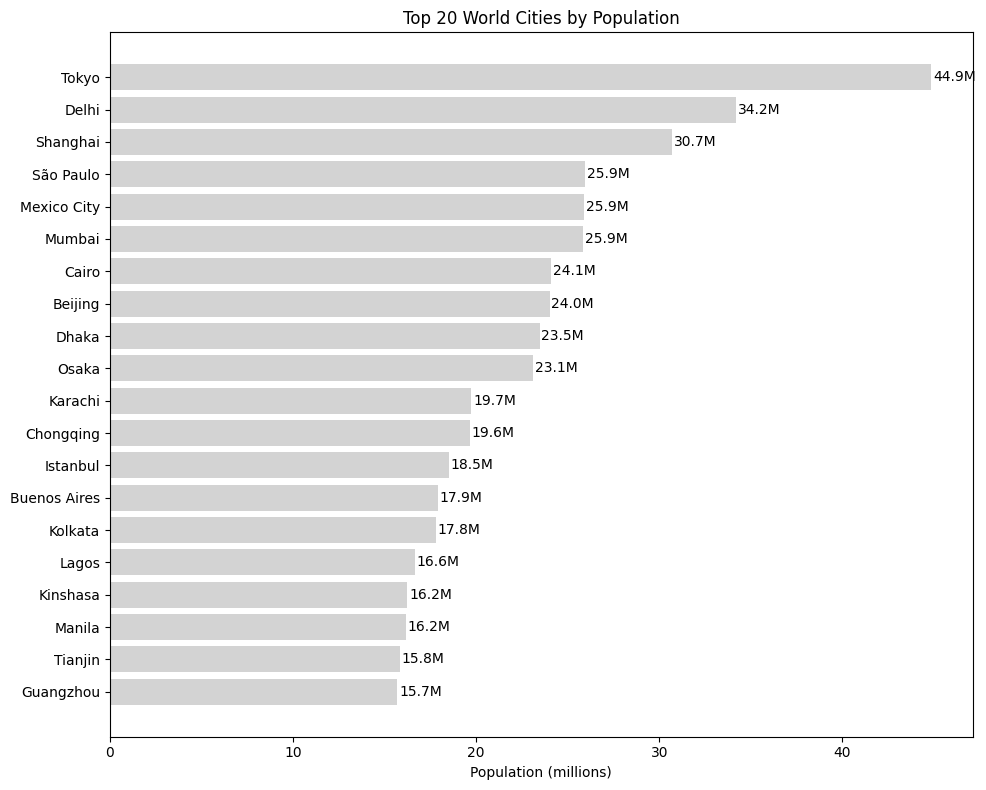

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    top20["city_clean"],
    top20["population"] / 1_000_000,
    color="lightgray"
)

plt.xlabel("Population (millions)")
plt.title("Top 20 World Cities by Population")

for i, value in enumerate(top20["population"]):
    plt.text(
        x = value / 1_000_000 + 0.1,
        y = i,
        s = f"{value/1_000_000:.1f}M",
        va="center",
        fontsize=10,
        color="black"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Takeaways

From this quick exploration of the world cities dataset, I learned that:
- The dataset focuses on large urban population centers since all cities have populations above 10 million.
- The average city is around 23 million people, but the distribution is skewed because a few extremely large cities exceed 40 million.
- The ASCII bar chart clearly shows that only a small group of mega-cities dominate, while most cities cluster just below them.
- This suggests that any “average-based” interpretation of urban characteristics must consider that policies affecting mega-cities may differ greatly from those appropriate for slightly smaller (but still very large) cities.

More broadly, this project reinforced how basic statistics (mean/median/mode) connect to observable patterns in real-world data, even when shown with a simple text-based visualization.

## Caveats and Limitations

A few important caveats are:
- The dataset only includes cities above a population threshold, so it does not represent small or medium-sized cities. It is a view of the global mega-city landscape.
- Population estimates come from external sources and may be measured at different times or with different methodologies.
- I analyzed only a single variable (population). A more complete study might consider geography, density, or changes over time.
- The ASCII visualization is intentionally simplified. It does not show trends or growth, and each bar hides a lot of detail about each city.